In [1]:
import numpy as np
import importlib
import image_wavelet
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, LogStretch

In [2]:
def generate_test_signals(n_samples=1024, fs=1000):
    """
    Generate various test signals for wavelet analysis
    
    Parameters:
    n_samples: Number of samples
    fs: Sampling frequency (Hz)
    
    Returns:
    dict: Dictionary containing different test signals
    """
    
    t = np.linspace(0, n_samples/fs, n_samples)
    signals = {}
    
    # 1. Pure sine wave
    signals['sine'] = np.sin(2 * np.pi * 50 * t)
    
    # 2. Chirp signal (frequency sweep)
    f0, f1 = 10, 200  # Start and end frequencies
    signals['chirp'] = np.sin(2 * np.pi * (f0 + (f1 - f0) * t / t[-1]) * t)
    
    # 3. Multi-frequency signal
    signals['multi_freq'] = (np.sin(2 * np.pi * 25 * t) + 
                            0.5 * np.sin(2 * np.pi * 100 * t) + 
                            0.3 * np.sin(2 * np.pi * 200 * t))
    
    # 4. Transient signals (brief bursts)
    burst1 = np.zeros_like(t)
    burst2 = np.zeros_like(t)
    
    # First burst at t=0.2s
    mask1 = (t >= 0.2) & (t <= 0.3)
    burst1[mask1] = np.sin(2 * np.pi * 150 * t[mask1])
    
    # Second burst at t=0.6s  
    mask2 = (t >= 0.6) & (t <= 0.7)
    burst2[mask2] = np.sin(2 * np.pi * 80 * t[mask2])
    
    signals['transients'] = burst1 + burst2
    
    # 5. Step function with high frequency noise
    step = np.ones_like(t)
    step[t < 0.5] = -1
    noise = 0.1 * np.random.randn(len(t))
    hf_noise = 0.05 * np.sin(2 * np.pi * 300 * t)
    signals['step_with_noise'] = step + noise + hf_noise
    
    # 6. Frequency modulated signal
    carrier_freq = 100
    mod_freq = 5
    mod_depth = 50
    signals['fm'] = np.sin(2 * np.pi * carrier_freq * t + 
                          mod_depth * np.sin(2 * np.pi * mod_freq * t))
    
    # 7. Amplitude modulated signal
    signals['am'] = (1 + 0.5 * np.sin(2 * np.pi * 5 * t)) * np.sin(2 * np.pi * 100 * t)
    
    # 8. Gaussian pulse
    center = n_samples // 2
    width = n_samples // 10
    gaussian_envelope = np.exp(-0.5 * ((np.arange(n_samples) - center) / width) ** 2)
    signals['gaussian_pulse'] = gaussian_envelope * np.sin(2 * np.pi * 100 * t)
    
    # 9. Noisy signal with embedded features
    base_signal = np.sin(2 * np.pi * 30 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)
    white_noise = 0.3 * np.random.randn(len(t))
    signals['noisy'] = base_signal + white_noise
    
    # 10. Piecewise signal (different frequencies in different segments)
    piecewise = np.zeros_like(t)
    n_thirds = len(t) // 3
    piecewise[:n_thirds] = np.sin(2 * np.pi * 20 * t[:n_thirds])
    piecewise[n_thirds:2*n_thirds] = np.sin(2 * np.pi * 80 * t[n_thirds:2*n_thirds])
    piecewise[2*n_thirds:] = np.sin(2 * np.pi * 150 * t[2*n_thirds:])
    signals['piecewise'] = piecewise
    
    return t, signals

def plot_signals(t, signals, max_plots=6):
    """Plot the generated signals"""
    signal_names = list(signals.keys())[:max_plots]
    n_plots = len(signal_names)
    
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 2*n_plots))
    if n_plots == 1:
        axes = [axes]
    
    for i, name in enumerate(signal_names):
        axes[i].plot(t, signals[name])
        axes[i].set_title(f'{name.replace("_", " ").title()} Signal')
        axes[i].set_xlabel('Time (s)')
        axes[i].set_ylabel('Amplitude')
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [3]:
t, test_signals = generate_test_signals(n_samples=1024, fs=1000)

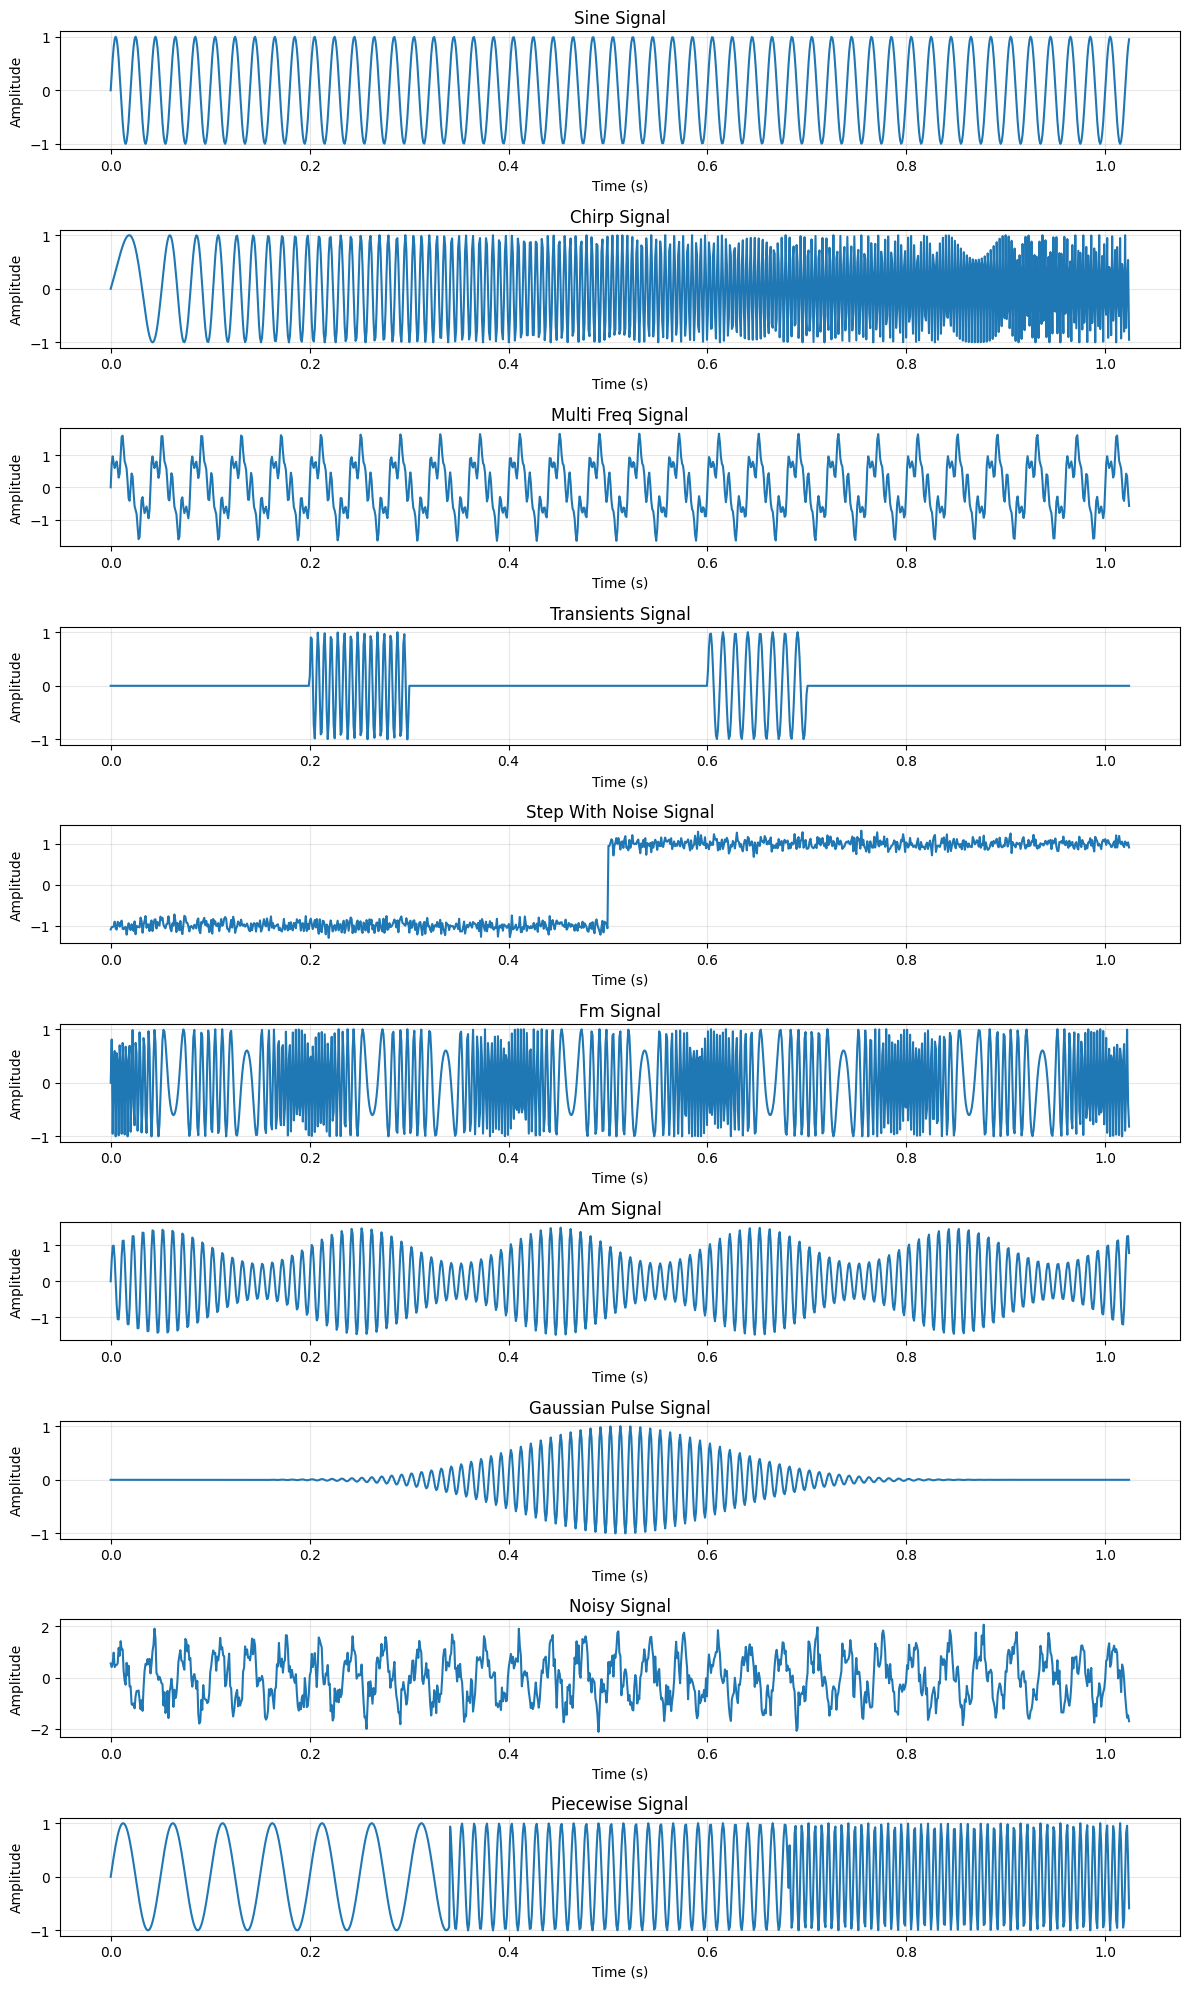

In [4]:
plot_signals(t, test_signals, max_plots=10)

In [5]:
print("Available test signals:")
for name in test_signals.keys():
    print(f"  - {name}")

Available test signals:
  - sine
  - chirp
  - multi_freq
  - transients
  - step_with_noise
  - fm
  - am
  - gaussian_pulse
  - noisy
  - piecewise


In [6]:
scales = np.logspace(1,9, num=100, base=2)/1024

In [7]:
dt = t[1] - t[0]

In [8]:
def test_signal(t, signal, scale):
    dt = t[1] - t[0]
    power_unbias, period, coi, global_ws_unbias, global_signif_unbias, sig95 = \
        image_wavelet.calculate_wps(dt, signal, scale, mother="MORLET", pad=1, lag1=0., siglvl=0.95)

    fig, ax = plt.subplots()
    im = ax.pcolormesh(t, 1/period, power_unbias,
    norm=ImageNormalize(vmin=np.nanpercentile(power_unbias, 1),
    vmax=np.nanpercentile(power_unbias, 99),
    stretch=LogStretch()),
    cmap="turbo")

    ax_ylim = ax.get_ylim()
    ax.fill_between(t, coi * 0 + 1/period[-1], 1/coi, facecolor="none",
    edgecolor="white", hatch='x')
    ax.plot(t, 1/coi, 'white')
    ax.set_ylim(ax_ylim)
    ax.set_ylabel("Frequency (Hz)")
    ax.set_xlabel("Time (s)")

    fig.colorbar(im, ax=ax)

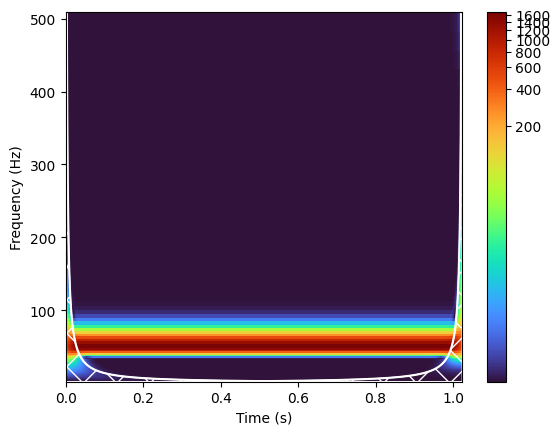

In [9]:
test_signal(t, test_signals['sine'], scales)

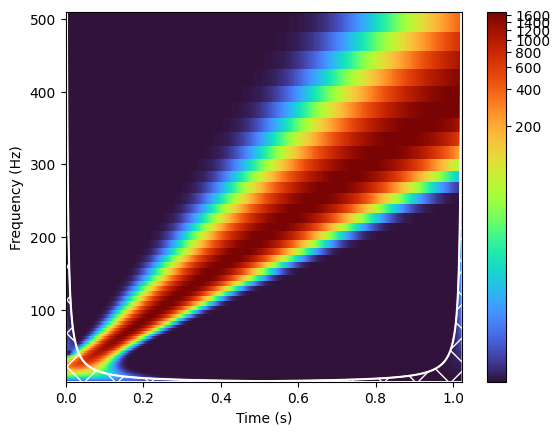

In [10]:
test_signal(t, test_signals['chirp'], scales)

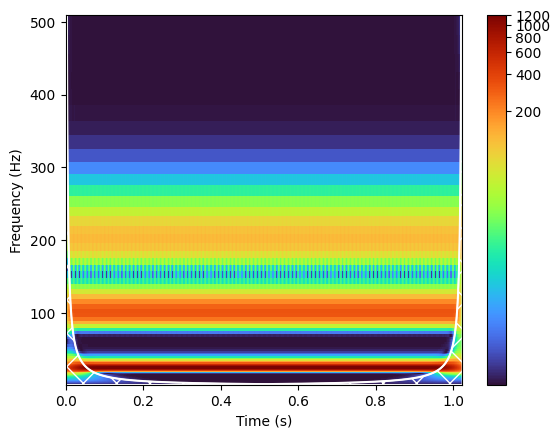

In [11]:
test_signal(t, test_signals['multi_freq'], scales)

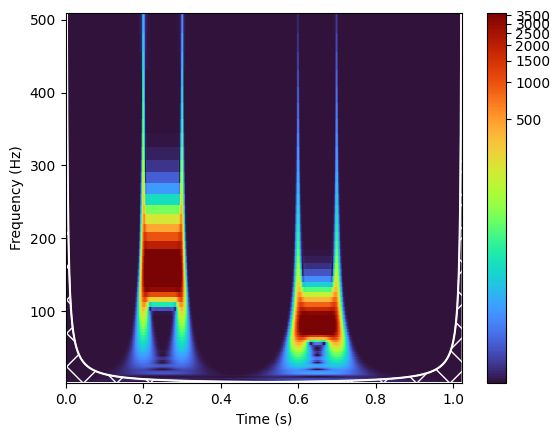

In [12]:
test_signal(t, test_signals['transients'], scales)

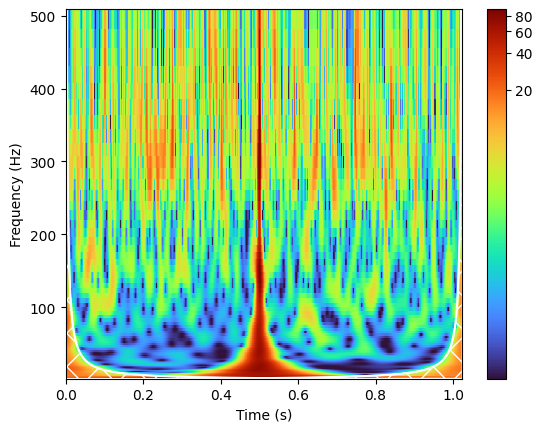

In [13]:
test_signal(t, test_signals['step_with_noise'], scales)

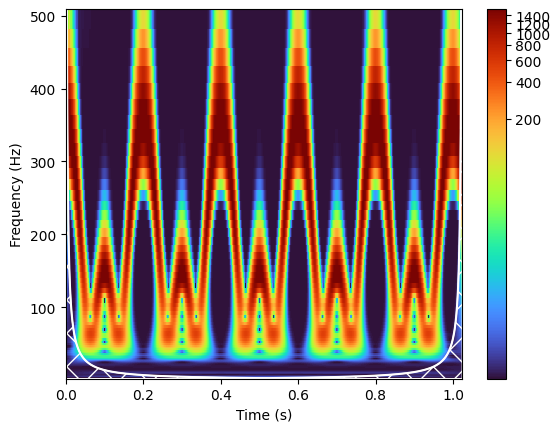

In [14]:
test_signal(t, test_signals['fm'], scales)

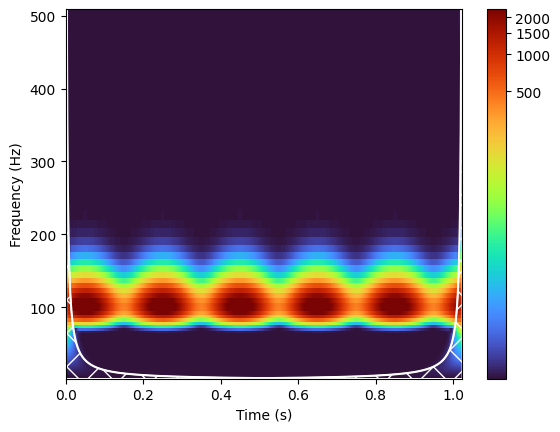

In [15]:
test_signal(t, test_signals['am'], scales)

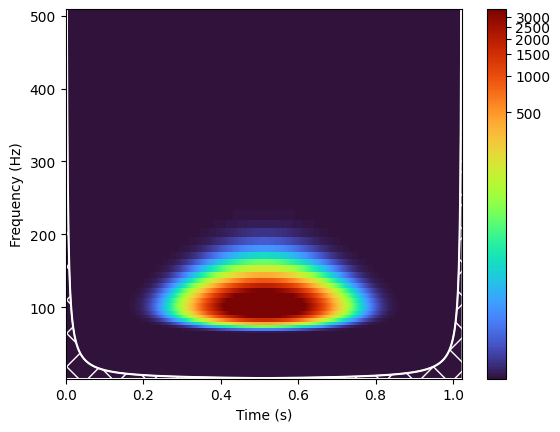

In [16]:
test_signal(t, test_signals['gaussian_pulse'], scales)

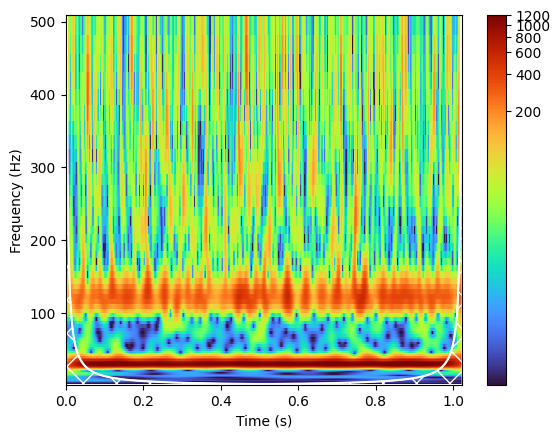

In [17]:
test_signal(t, test_signals['noisy'], scales)

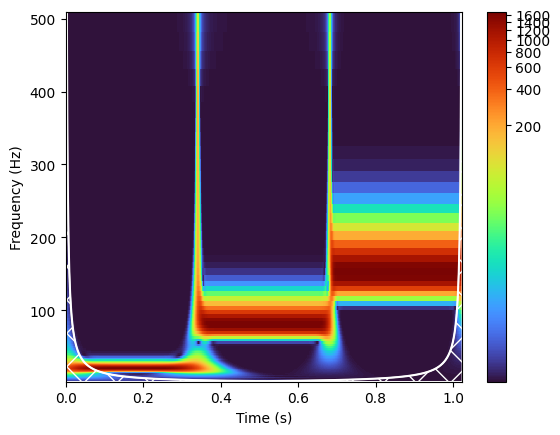

In [18]:
test_signal(t, test_signals['piecewise'], scales)

In [19]:
def generate_test_signals(n_samples=1024, fs=1000):
    test_image = np.zeros((10, 10, n_samples))

    t = np.linspace(0, n_samples/fs, n_samples)

    for ii in range(10):
        for jj in range(10):

            burst1 = np.zeros_like(t)
            burst2 = np.zeros_like(t)
            
            t1_start = np.random.uniform(0, 1)
            t1_end = t1_start + 0.1
            mask1 = (t >= t1_start) & (t <= t1_end)
            if ii < 5:
                t1_freq = np.random.normal(150,10)
            else:
                t1_freq = np.random.normal(100,10)
            burst1[mask1] = np.sin(2 * np.pi * t1_freq * t[mask1])
            
            test_image[jj,ii,:] = burst1

    return t, test_image

In [20]:
t,test_image = generate_test_signals()

In [21]:
test_wps = image_wavelet.WPSImage(scales, test_image, t,lag1=0.72)

In [22]:
test_wps._wps_image(ncpu=8)

/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:150: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi = np.nanmean(power_unbias_coi, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:151: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi_sig = np.nanmean(power_unbias_coi_sig, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:150: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi = np.nanmean(power_unbias_coi, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:151: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi_sig = np.nanmean(power_unbias_coi_sig, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:150: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi = np.nanmean(power_unbias_coi, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:151: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi_sig = np.nanmean(power_unbias_coi_sig, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:1

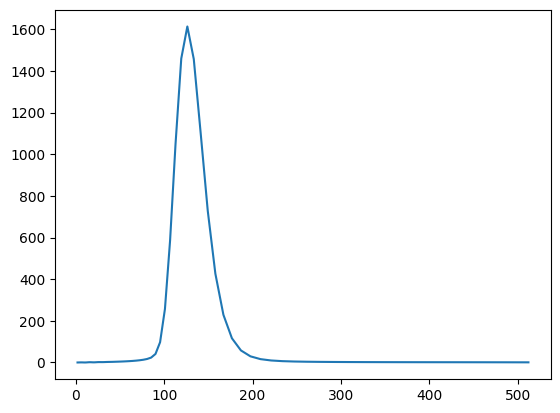

In [23]:
plt.plot(1/scales,test_wps.global_ws_unbias[4,2])

/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:150: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi = np.nanmean(power_unbias_coi, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:151: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi_sig = np.nanmean(power_unbias_coi_sig, axis=1)


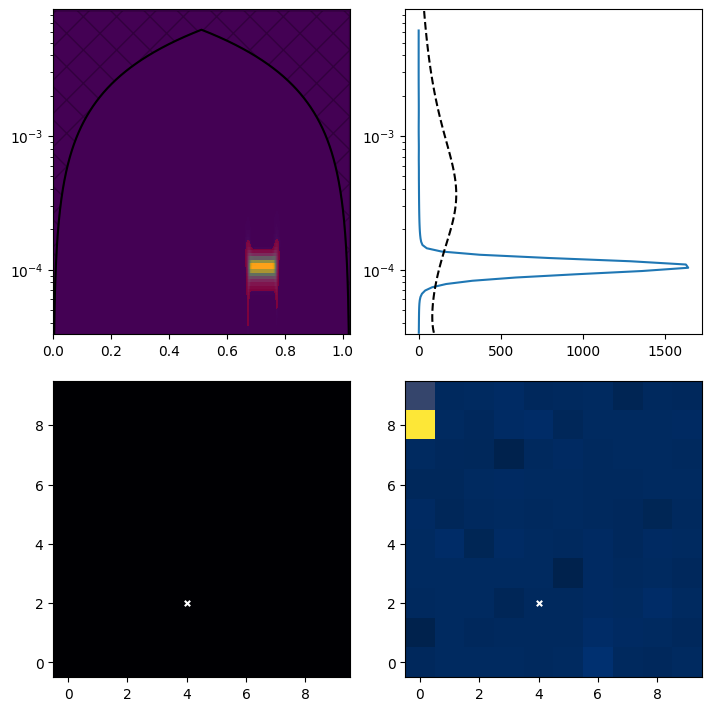

In [24]:
test_wps.plot_single_ws(4,2)